文件: E:\测试数据\模量\压缩\20260408\1.csv
  数据点数: 2131
  拟合斜率(压缩模量): 1.8237 MPa
文件: E:\测试数据\模量\压缩\20260408\2.csv
  数据点数: 2783
  拟合斜率(压缩模量): 1.5334 MPa
文件: E:\测试数据\模量\压缩\20260408\3.csv
  数据点数: 3123
  拟合斜率(压缩模量): 2.1455 MPa
文件: E:\测试数据\模量\压缩\20260408\4.csv
  数据点数: 1842
  拟合斜率(压缩模量): 2.0914 MPa
文件: E:\测试数据\模量\压缩\20260408\5.csv
  数据点数: 2414
  拟合斜率(压缩模量): 1.9720 MPa
文件: E:\测试数据\模量\压缩\20260408\6.csv
  数据点数: 4694
  拟合斜率(压缩模量): 3.7818 MPa
文件: E:\测试数据\模量\压缩\20260408\7.csv
  数据点数: 2178
  拟合斜率(压缩模量): 1.7113 MPa
文件: E:\测试数据\模量\压缩\20260408\8.csv
  数据点数: 1847
  拟合斜率(压缩模量): 1.5984 MPa


,file,slope_MPa
0,E:\测试数据\模量\压缩\20260408\1.csv,1.823650
1,E:\测试数据\模量\压缩\20260408\2.csv,1.533406
2,E:\测试数据\模量\压缩\20260408\3.csv,2.145459
3,E:\测试数据\模量\压缩\20260408\4.csv,2.091425
4,E:\测试数据\模量\压缩\20260408\5.csv,1.972043
5,E:\测试数据\模量\压缩\20260408\6.csv,3.781795
6,E:\测试数据\模量\压缩\20260408\7.csv,1.711269
7,E:\测试数据\模量\压缩\20260408\8.csv,1.598408


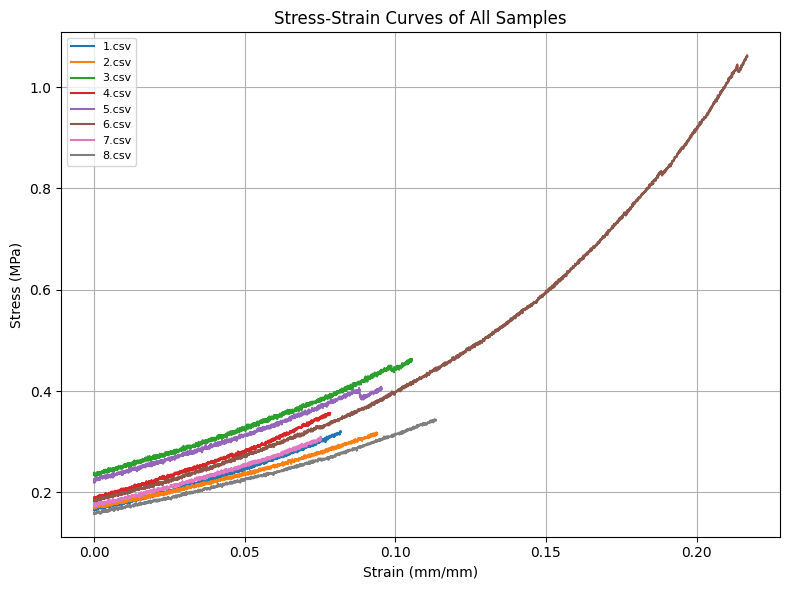

In [1]:
import os
import pandas as pd
import numpy as np

# TODO: 修改为你实际存放压缩实验 csv 的文件夹
root_dir = r"E:\测试数据\模量\压缩\20260408"

stress_col_name = "应力(MPa)"
strain_col_name = "应变(mm/mm)"

results = []

def load_stress_strain(csv_path):
    # 跳过前 6 行，让第 7 行作为表头
    df = None
    for enc in ("utf-8-sig", "utf-8", "gbk"):
        try:
            df = pd.read_csv(
                csv_path,
                skiprows=6,        # 关键：跳过 6 行
                encoding=enc,
                engine="python",
                sep=None,          # 自动识别分隔符
                on_bad_lines="skip"
            )
            break
        except Exception:
            df = None
    if df is None:
        raise UnicodeDecodeError(f"无法用常见编码解码文件: {csv_path}")

    if stress_col_name not in df.columns or strain_col_name not in df.columns:
        raise ValueError(f"表头行中未找到需要的列: {csv_path}\n当前列: {df.columns.tolist()}")

    stress = pd.to_numeric(df[stress_col_name], errors="coerce")
    strain = pd.to_numeric(df[strain_col_name], errors="coerce")

    mask = stress.notna() & strain.notna()
    stress = stress[mask]
    strain = strain[mask]

    if len(stress) < 2:
        raise ValueError(f"有效数据点少于 2 个，无法拟合斜率: {csv_path}")

    return strain, stress

def calc_slope(strain, stress):
    """
    使用一元线性拟合 y = kx + b 得到斜率 k。
    """
    k, b = np.polyfit(strain.values, stress.values, 1)
    return k

# 遍历 root_dir 下所有 csv 文件
for dirpath, dirnames, filenames in os.walk(root_dir):
    for fname in filenames:
        if fname.lower().endswith(".csv"):
            fpath = os.path.join(dirpath, fname)
            try:
                strain, stress = load_stress_strain(fpath)
                k = calc_slope(strain, stress)
                results.append({"file": fpath, "slope_MPa": k})
                print(f"文件: {fpath}")
                print(f"  数据点数: {len(strain)}")
                print(f"  拟合斜率(压缩模量): {k:.4f} MPa")
            except Exception as e:
                print(f"[错误] 处理文件失败: {fpath}")
                print(f"   原因: {e}")

# 汇总结果成一个 DataFrame，方便后续分析
if results:
    df_results = pd.DataFrame(results)
    display(df_results)
else:
    print("未找到任何成功处理的 csv 文件。")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for result in results:
    fpath = result["file"]
    try:
        strain, stress = load_stress_strain(fpath)
        plt.plot(strain, stress, label=os.path.basename(fpath))
    except Exception as e:
        print(f"[可视化跳过] {fpath}: {e}")

plt.xlabel("Strain (mm/mm)")
plt.ylabel("Stress (MPa)")
plt.title("Stress-Strain Curves of All Samples")
plt.legend(fontsize=8, loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()